# preparation


In [54]:
!pip install google-search-results
!pip install -q google-colab-selenium
!pip install selenium webdriver-manager
!wget -q -O - https://dl-ssl.google.com/linux/linux_signing_key.pub | apt-key add -
!echo "deb [arch=amd64] http://dl.google.com/linux/chrome/deb/ stable main" >> /etc/apt/sources.list.d/google-chrome.list
!apt-get update
!apt-get install -y google-chrome-stable

OK
Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://dl.google.com/linux/chrome-stable/deb stable InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 http://dl.google.com/linux/chrome/deb stable InRelease
Hit:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: http://dl.google.com/linux/chrome/deb/dists/stable/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
W: Target Packages (main/binary-amd64/Packages) is config

In [55]:
import requests
from bs4 import BeautifulSoup
from serpapi import GoogleSearch
import google_colab_selenium as gs
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options as ChromeOptions
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.chrome.service import Service
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import pytz
from datetime import datetime
from sklearn import linear_model
import seaborn as sns
from google.colab import userdata

# beautfulsoup

In [56]:
from bs4.filter import StringMatchRule

url = "https://www.ebay.com/n/all-categories"
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')
motorcycles_title=soup.find(string='Top Vehicle Makes ')
motorcycles_div=motorcycles_title.find_parent('div')
categories=[]
category_links=[]
category_data=[]
for link in motorcycles_div.find_all('a', href=True):
  name_catgory=link.text
  link_catgory=link['href']
  if name_catgory:
    categories.append(name_catgory)
    category_links.append(link_catgory)
    category_data.append([name_catgory,link_catgory])
print(category_data)

[['Top Vehicle Makes ', 'https://www.ebay.com/n/all-makes'], ['Mercedes-Benz - Top Vehicle Makes ', 'https://www.ebay.com/b/Mercedes-Benz/bn_7000694241'], ['Honda - Top Vehicle Makes ', 'https://www.ebay.com/b/Honda/bn_7000694499'], ['Toyota - Top Vehicle Makes ', 'https://www.ebay.com/b/Toyota/bn_7000694636'], ['BMW - Top Vehicle Makes ', 'https://www.ebay.com/b/BMW/bn_7000694732'], ['Ford - Top Vehicle Makes ', 'https://www.ebay.com/b/Ford/bn_7000694433'], ['Jeep - Top Vehicle Makes ', 'https://www.ebay.com/b/Jeep/bn_7000694804'], ['Yamaha - Top Vehicle Makes ', 'https://www.ebay.com/b/Yamaha/bn_7000694240'], ['Kawasaki - Top Vehicle Makes ', 'https://www.ebay.com/b/Kawasaki/bn_7117794160'], ['Cadillac - Top Vehicle Makes ', 'https://www.ebay.com/b/Cadillac/bn_7000694555'], ['GMC - Top Vehicle Makes ', 'https://www.ebay.com/b/GMC/bn_7000881011'], ['View all Vehicle Makes ', 'https://www.ebay.com/n/all-makes']]


In [57]:
df_categories=pd.DataFrame(category_data,columns=["catgory","link"])
df_categories.to_csv("data_catogory_save.csv",index=False)
print(df_categories)

                               catgory  \
0                   Top Vehicle Makes    
1   Mercedes-Benz - Top Vehicle Makes    
2           Honda - Top Vehicle Makes    
3          Toyota - Top Vehicle Makes    
4             BMW - Top Vehicle Makes    
5            Ford - Top Vehicle Makes    
6            Jeep - Top Vehicle Makes    
7          Yamaha - Top Vehicle Makes    
8        Kawasaki - Top Vehicle Makes    
9        Cadillac - Top Vehicle Makes    
10            GMC - Top Vehicle Makes    
11             View all Vehicle Makes    

                                                 link  
0                    https://www.ebay.com/n/all-makes  
1   https://www.ebay.com/b/Mercedes-Benz/bn_700069...  
2          https://www.ebay.com/b/Honda/bn_7000694499  
3         https://www.ebay.com/b/Toyota/bn_7000694636  
4            https://www.ebay.com/b/BMW/bn_7000694732  
5           https://www.ebay.com/b/Ford/bn_7000694433  
6           https://www.ebay.com/b/Jeep/bn_7000694804  
7    

# API


In [58]:
url = "https://www.searchapi.io/api/v1/search"
params = {
    "engine": "ebay_search",
    "q": "motorcycles",
    "api_key": userdata.get('MY_API_KEY')
}

response = requests.get(url, params=params)
search_results = response.json()
organic_listings = search_results.get("organic_results", [])
harley_listings = []
honda_listings = []
suzuki_listings = []
kawasaki_listings = []
yamaha_listings = []
bmw_listings = []
other_listings = []
all_listings = []

for model in organic_listings:
    title = model.get("title", "No Title")
    price = model.get("extracted_price", "No Price")
    link = model.get("link", "No Link")
    all_listings.append((title, price, link))

    if "Harley" in title:
        harley_listings.append((title, price, link))
    elif "Honda" in title:
        honda_listings.append((title, price, link))
    elif "Suzuki" in title:
        suzuki_listings.append((title, price, link))
    elif "Kawasaki" in title:
        kawasaki_listings.append((title, price, link))
    elif "Yamaha" in title:
        yamaha_listings.append((title, price, link))
    elif "BMW" in title:
        bmw_listings.append((title, price, link))
    else:
        other_listings.append((title, price, link))


In [59]:
df_listings=pd.DataFrame(data=all_listings, columns=["model","price","link"])
df_listings.to_csv("data_save.csv",index=False)
print(df_listings)

                                                model     price  \
0                   2013 Harley-Davidson Street Glide  10500.00   
1                          2023 HARLEY-DAVIDSON FLFBS  18999.00   
2                       2020 Harley-Davidson Iron 883   7000.00   
3                         2004 HARLEY-DAVIDSON FLSTCI   6250.00   
4                                2014 HUSQVARNA TC250   3800.00   
5                                      1939 TWN B204E   5499.99   
6                                 1985 Honda CB700 SC   3500.00   
7                                 2007 PIAGGIO BV 500   3000.00   
8                                    1977 Motorcycles   5500.00   
9                      2024 Royal Enfield Motorcycles   3994.00   
10                             1986 Honda Motorcycles   2650.00   
11                                  2012 Honda XR650L   4000.00   
12                                 1990 Honda VFR750F   3600.00   
13                   1979 Harley-Davidson Motorcycles   5200.0

In [60]:
df_harley=pd.DataFrame(data=harley_listings, columns=["model","price","link"])
df_harley.to_csv("data_HarleyDavidson_save.csv",index=False)
print(df_harley)

df_honda=pd.DataFrame(data=honda_listings, columns=["model","price","link"])
df_honda.to_csv("data_Honda_save.csv",index=False)
print(df_honda)

df_suzuki=pd.DataFrame(data=suzuki_listings, columns=["model","price","link"])
df_suzuki.to_csv("data_Suzuki_save.csv",index=False)
print(df_suzuki)

df_kawasaki=pd.DataFrame(data=kawasaki_listings, columns=["model","price","link"])
df_kawasaki.to_csv("data_Kawasaki_save.csv",index=False)
print(df_kawasaki)

df_yamaha=pd.DataFrame(data=yamaha_listings, columns=["model","price","link"])
df_yamaha.to_csv("data_Yamaha_save.csv",index=False)
print(df_yamaha)

df_bmw=pd.DataFrame(data=bmw_listings, columns=["model","price","link"])
df_bmw.to_csv("data_BMW_save.csv",index=False)
print(df_bmw)

                                               model    price  \
0                  2013 Harley-Davidson Street Glide  10500.0   
1                      2020 Harley-Davidson Iron 883   7000.0   
2                   1979 Harley-Davidson Motorcycles   5200.0   
3                   2020 Harley-Davidson Motorcycles   7995.0   
4                     1962 Harley-Davidson Duo Glide   9500.0   
5                            1967 Harley-Davidson FL   7327.0   
6  2004 Custom Built Motorcycles 80 cubic inch EV...  12500.0   

                                    link  
0  https://www.ebay.com/itm/168482120229  
1  https://www.ebay.com/itm/227377708799  
2  https://www.ebay.com/itm/800223253577  
3  https://www.ebay.com/itm/407011239195  
4  https://www.ebay.com/itm/358741940179  
5  https://www.ebay.com/itm/127946830919  
6  https://www.ebay.com/itm/117249253775  
                    model    price                                   link
0     1985 Honda CB700 SC   3500.0  https://www.ebay.com/itm/

# Selenium

In [61]:
print("Opening browser...")
chrome_options = Options()
chrome_options.add_argument("--headless=new")
chrome_options.add_argument('--no-sandbox')
chrome_options.add_argument('--disable-dev-shm-usage')
service = Service(ChromeDriverManager().install())
driver = webdriver.Chrome(service=service, options=chrome_options)
url = "https://www.ebay.com/urw/SHOEI-RF-1000-Full-Face-Motorcycle-Helmet-Black-Large-RF1000/product-reviews/1511846299?pgn=2"
driver.get(url)
print("Loading page...")
time.sleep(3)
reviews = driver.find_elements(By.CSS_SELECTOR, ".ebay-review-section")
print(f"Awesome! Found {len(reviews)} reviews on this page.\n")
for review in reviews:
    try:
        title = review.find_element(By.CSS_SELECTOR, ".review-item-title").text
        author = review.find_element(By.CSS_SELECTOR, ".review-item-author").text
        content = review.find_element(By.CSS_SELECTOR, ".review-item-content").text
        print(f"Title: {title}")
        print(f"Author: {author}")
        print(f"Review: {content}")
        print("-" * 30)

    except Exception:
        pass
driver.quit()
print("All done!")

Opening browser...
Loading page...
Awesome! Found 7 reviews on this page.

Title: Love it!!
Author: kelinga79
Review: I love my shoei helmet! It's stylish and super comfy!!
------------------------------
Title: Helmet was just like what was posted
Author: D3yl7NmcRDC@Del...
Review: Was very happy with the helmet when came
------------------------------
Title: one of my favorite
Author: hobbies_and_coffee
Review: thanks for the lid
------------------------------
Title: V-ROD helmet
Author: penaous2014
Review: normaly i dont like pinstrip on helmets . this one was done well.
------------------------------
Title: Beautiful helmet!
Author: zac-1102
Review: Super clean!
------------------------------
All done!


# Visualizing&NETWORK

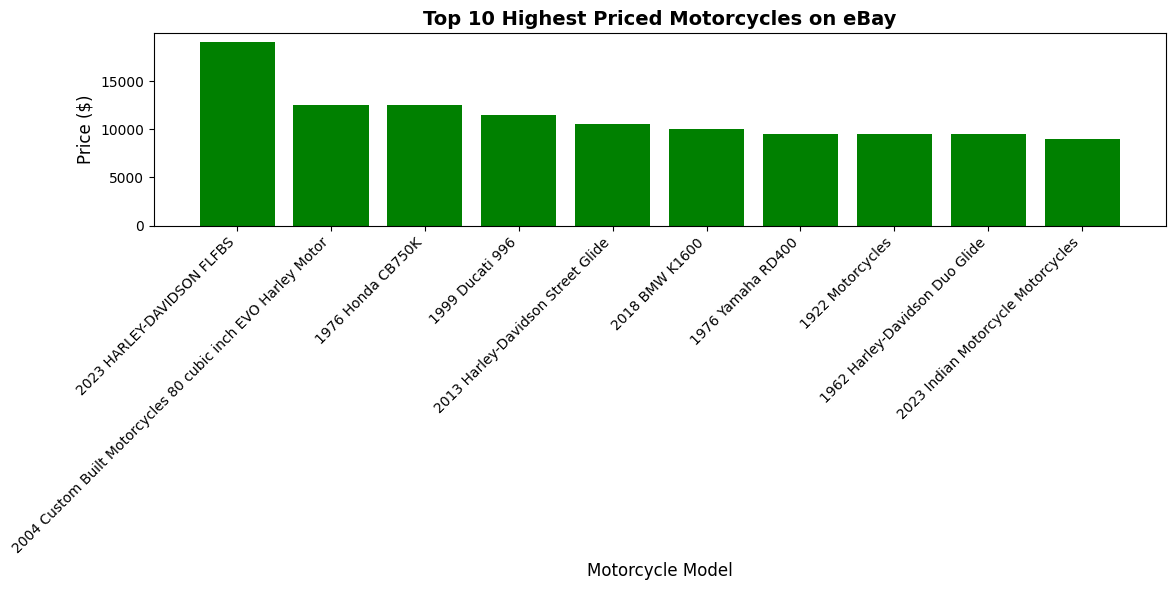

In [62]:
dfd_sorted = df_listings.sort_values(by='price', ascending=False)
top_10 = dfd_sorted.head(10)
plt.figure(figsize=(12, 6))
plt.bar(top_10["model"], top_10["price"], color='green')
plt.title("Top 10 Highest Priced Motorcycles on eBay", fontsize=14, fontweight='bold')
plt.xlabel("Motorcycle Model", fontsize=12)
plt.ylabel("Price ($)", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

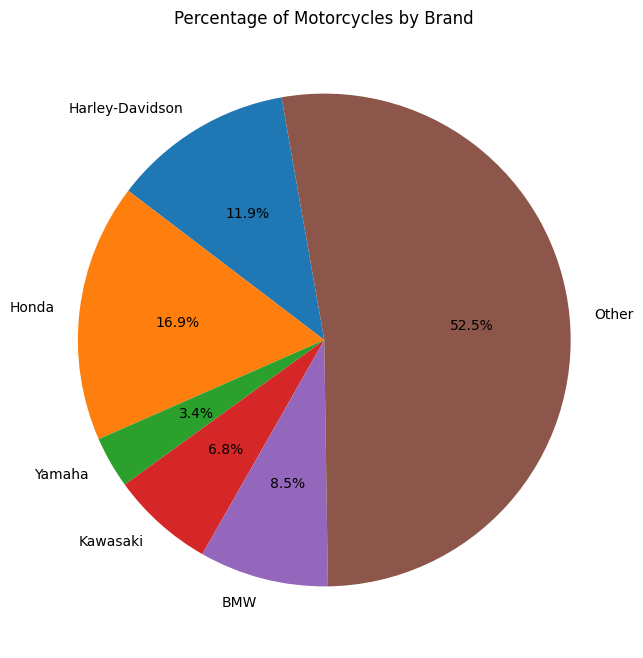

In [63]:
counts = [
    len(harley_listings),
    len(honda_listings),
    len(yamaha_listings),
    len(kawasaki_listings),
    len(bmw_listings),
    len(other_listings)
]
labels = ['Harley-Davidson', 'Honda', 'Yamaha', 'Kawasaki', 'BMW', 'Other']
plt.figure(figsize=(8, 8))
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=100)
plt.title("Percentage of Motorcycles by Brand")
plt.show()

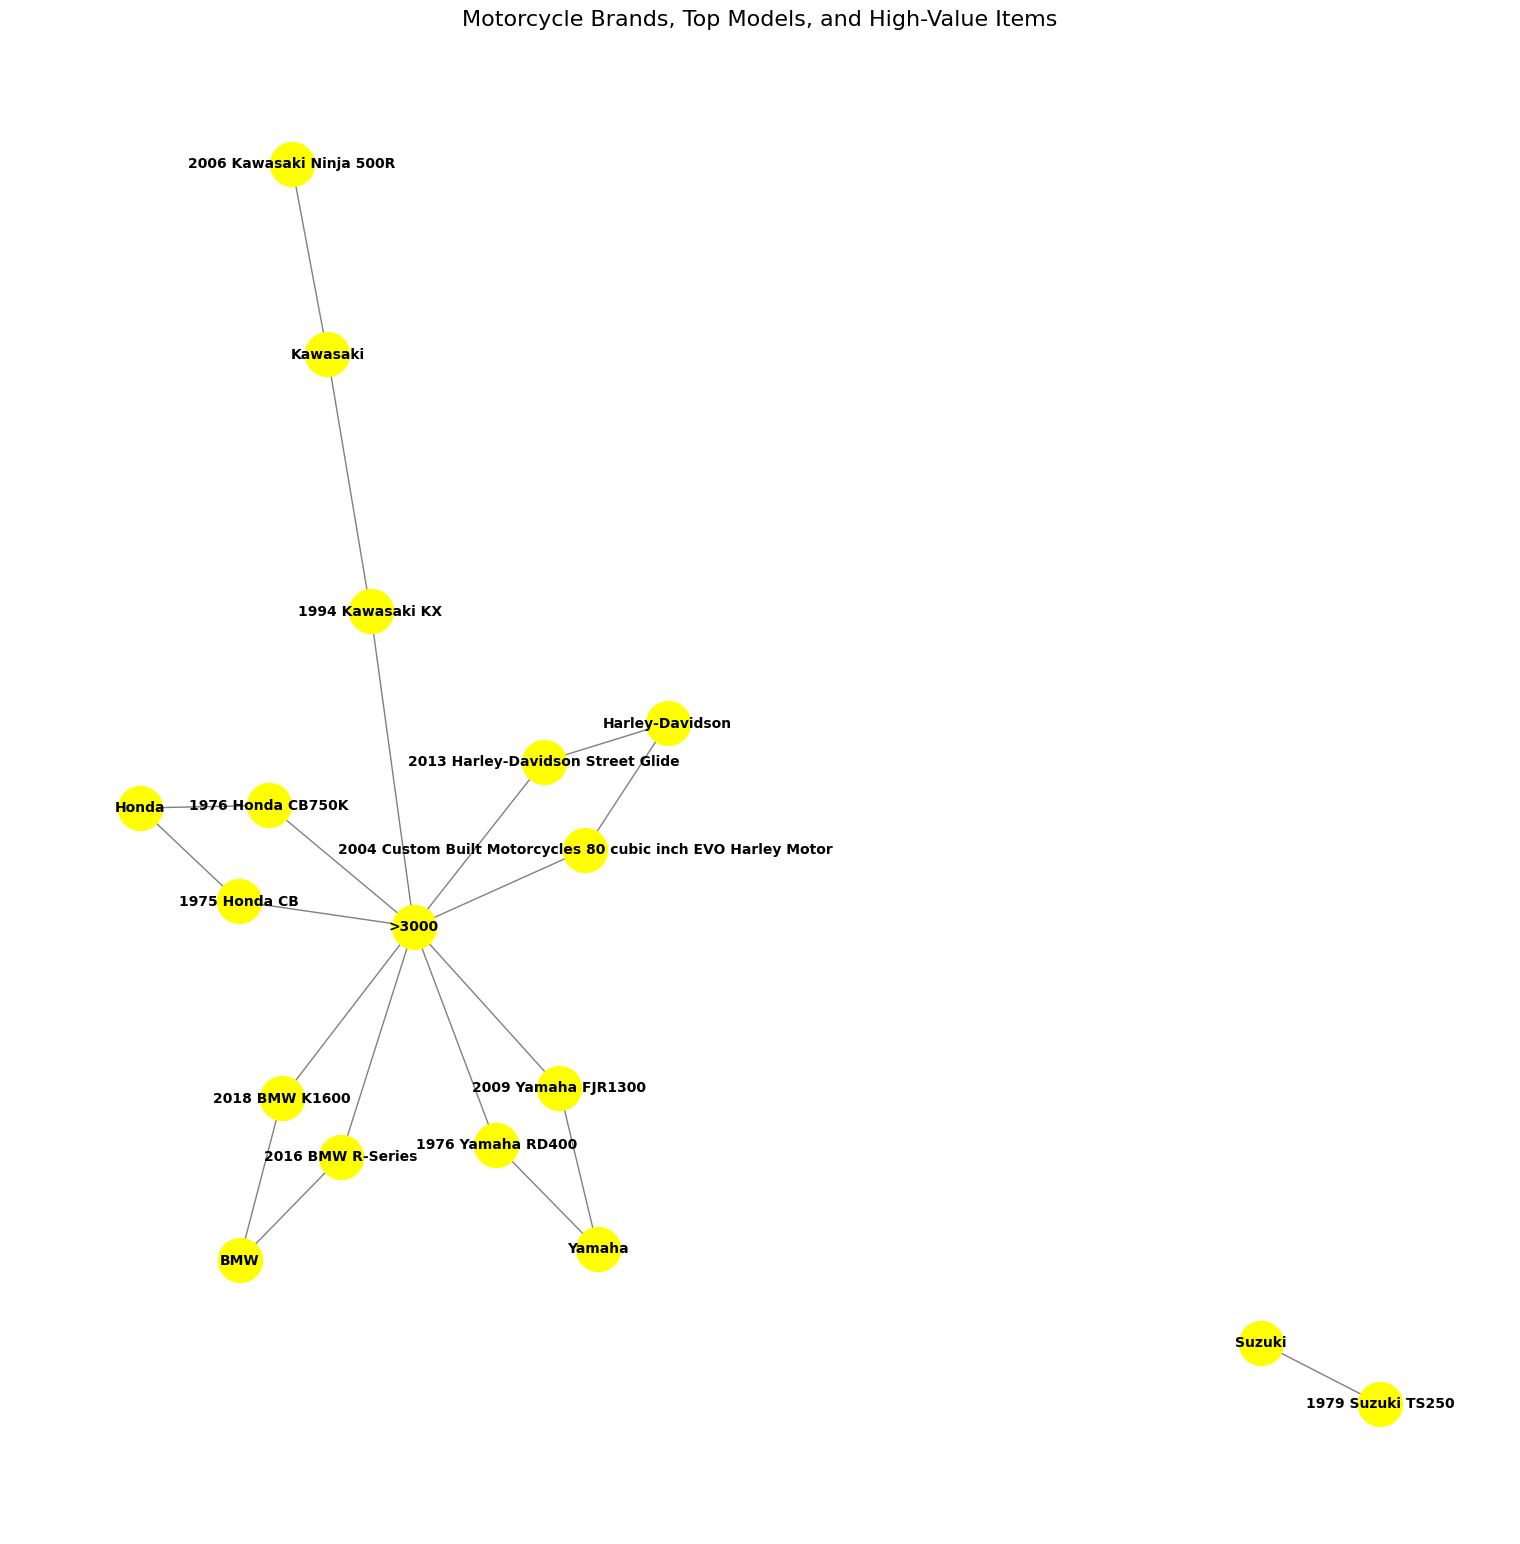

In [64]:
G = nx.Graph()

brand_dataframes = {
    "Harley-Davidson": df_harley,
    "Honda": df_honda,
    "Suzuki": df_suzuki,
    "Kawasaki": df_kawasaki,
    "Yamaha": df_yamaha,
    "BMW": df_bmw
}

for brand_name, df_brand in brand_dataframes.items():
        df_brand['price'] = pd.to_numeric(df_brand['price'], errors='coerce')
        df_brand = df_brand.dropna(subset=['price'])

        if not df_brand.empty:
            top_models = df_brand.sort_values(by='price', ascending=False).head(2)
            for index, row in top_models.iterrows():
                model_name = row['model']
                price = row['price']
                G.add_edge(brand_name, model_name)
                if price > 3000:
                    G.add_edge(model_name, ">3000")

plt.figure(figsize=(15, 15))
nx.draw(G, with_labels=True, node_color="yellow", node_size=1000, font_size=10, font_weight="bold", edge_color="gray")
plt.title("Motorcycle Brands, Top Models, and High-Value Items", size=16)
plt.show()

# HEATMAP&3D


[[0, 3, 2, 0, 0], [0, 1, 1, 0, 0], [3, 0, 1, 0, 0], [0, 1, 0, 0, 0], [0, 8, 1, 1, 0], [0, 0, 5, 2, 0]]


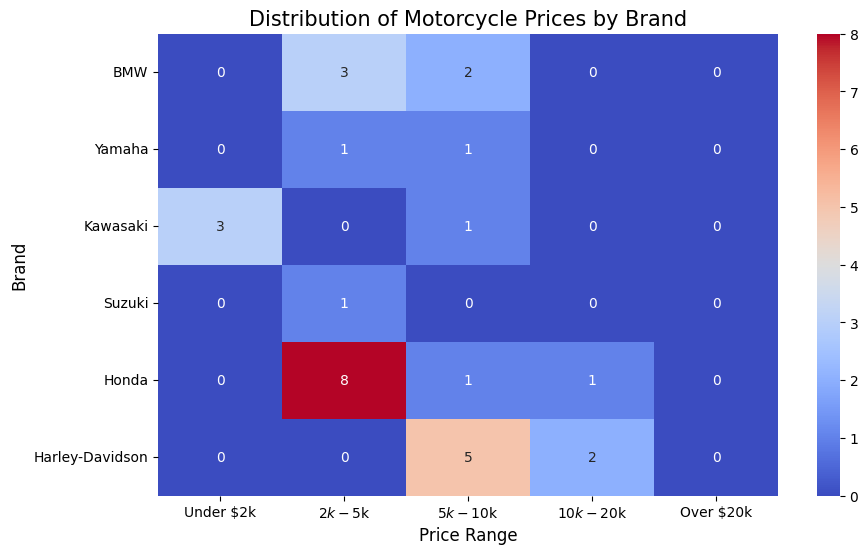

In [65]:
price_BMW = df_bmw["price"]
price_Yamaha = df_yamaha["price"]
price_Kawasaki = df_kawasaki["price"]
price_Suzuki = df_suzuki["price"]
price_Honda = df_honda["price"]
price_HarleyDavidson = df_harley["price"]
all_brand_prices = [price_BMW, price_Yamaha, price_Kawasaki, price_Suzuki, price_Honda, price_HarleyDavidson]
def count_prices(prices_list):
    under_2k  = 0
    from_2_5  = 0
    from_5_10 = 0
    from_10_20 = 0
    over_20k  = 0

    for price in prices_list:
        if price < 2000:
            under_2k = under_2k + 1
        elif price < 5000:
            from_2_5 = from_2_5 + 1
        elif price < 10000:
            from_5_10 = from_5_10 + 1
        elif price < 20000:
            from_10_20 = from_10_20 + 1
        else:
            over_20k = over_20k + 1

    return [under_2k, from_2_5, from_5_10, from_10_20, over_20k]
date_table=[]
for brand in all_brand_prices:
    date_table.append(count_prices(brand))
print(date_table)
brands = ["BMW", "Yamaha", "Kawasaki", "Suzuki", "Honda", "Harley-Davidson"]
price_buckets = ["Under $2k", "$2k-$5k", "$5k-$10k", "$10k-$20k", "Over $20k"]
df_heatmap = pd.DataFrame(date_table, index=brands, columns=price_buckets)
plt.figure(figsize=(10, 6))
sns.heatmap(df_heatmap, annot=True,cmap='coolwarm')
plt.title("Distribution of Motorcycle Prices by Brand", fontsize=15)
plt.xlabel("Price Range", fontsize=12)
plt.ylabel("Brand", fontsize=12)
plt.show()

/tmp/ipykernel_20330/2021059341.py:69: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


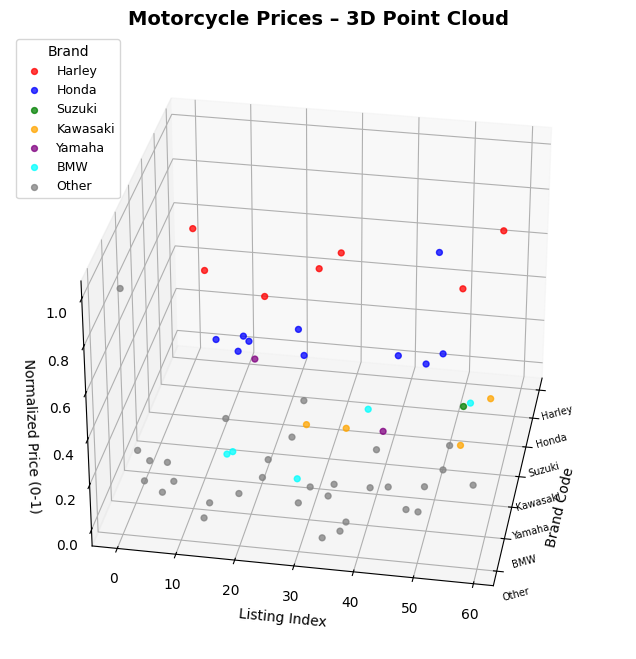

In [66]:
dfd_3d = df_listings.copy()
dfd_3d["price"] = pd.to_numeric(dfd_3d["price"], errors="coerce")
dfd_3d = dfd_3d.dropna(subset=["price"])
dfd_3d = dfd_3d[dfd_3d["price"] > 0].reset_index(drop=True)


def get_brand(title):
    if "Harley"   in title: return "Harley"
    if "Honda"    in title: return "Honda"
    if "Suzuki"   in title: return "Suzuki"
    if "Kawasaki" in title: return "Kawasaki"
    if "Yamaha"   in title: return "Yamaha"
    if "BMW"      in title: return "BMW"
    return "Other"

brand_map = {"Harley": 1, "Honda": 2, "Suzuki": 3,
             "Kawasaki": 4, "Yamaha": 5, "BMW": 6, "Other": 7}

dfd_3d["brand"]      = dfd_3d["model"].apply(get_brand)
dfd_3d["brand_code"] = dfd_3d["brand"].map(brand_map)

pmin = dfd_3d["price"].min()
pmax = dfd_3d["price"].max()
dfd_3d["price_norm"] = (dfd_3d["price"] - pmin) / (pmax - pmin)

X = list(dfd_3d["brand_code"])
Y = list(dfd_3d.index)
Z = list(dfd_3d["price_norm"])


brand_colors = {
    "Harley":   "red",
    "Honda":    "blue",
    "Suzuki":   "green",
    "Kawasaki": "orange",
    "Yamaha":   "purple",
    "BMW":      "cyan",
    "Other":    "gray",
}

fig = plt.figure(figsize=(12, 8))
ax  = fig.add_subplot(projection='3d')

for brand, color in brand_colors.items():
    mask = dfd_3d["brand"] == brand
    if mask.sum() == 0:
        continue
    ax.scatter(
        dfd_3d.loc[mask, "brand_code"],
        dfd_3d.loc[mask].index,
        dfd_3d.loc[mask, "price_norm"],
        color=color,
        s=18,
        label=brand,
        alpha=0.75,
    )

ax.set_xlabel("Brand Code")
ax.set_ylabel("Listing Index")
ax.set_zlabel("Normalized Price (0-1)")
ax.set_title("Motorcycle Prices – 3D Point Cloud", fontsize=14, fontweight="bold")

ax.set_xticks(list(brand_map.values()))
ax.set_xticklabels(list(brand_map.keys()), fontsize=7, rotation=15)

ax.view_init(30, 10)
ax.legend(loc="upper left", fontsize=9, title="Brand")

plt.tight_layout()
plt.draw()
plt.show()

# Bounc

In [67]:
cairo_tz = pytz.timezone("Africa/Cairo")
current_date = pd.to_datetime(datetime.now(cairo_tz).strftime("%Y-%m-%d"))
avg_price = pd.to_numeric(df_listings["price"], errors="coerce").mean()
file_path = "market_history.csv"
try:
    df_market_history = pd.read_csv(file_path, parse_dates=["Date"], index_col="Date")
except FileNotFoundError:
    dftime = pd.DataFrame(columns=["avg_price"])
    dftime.index.name = "Date"
dftime.loc[current_date] = [avg_price]
dftime.to_csv(file_path)

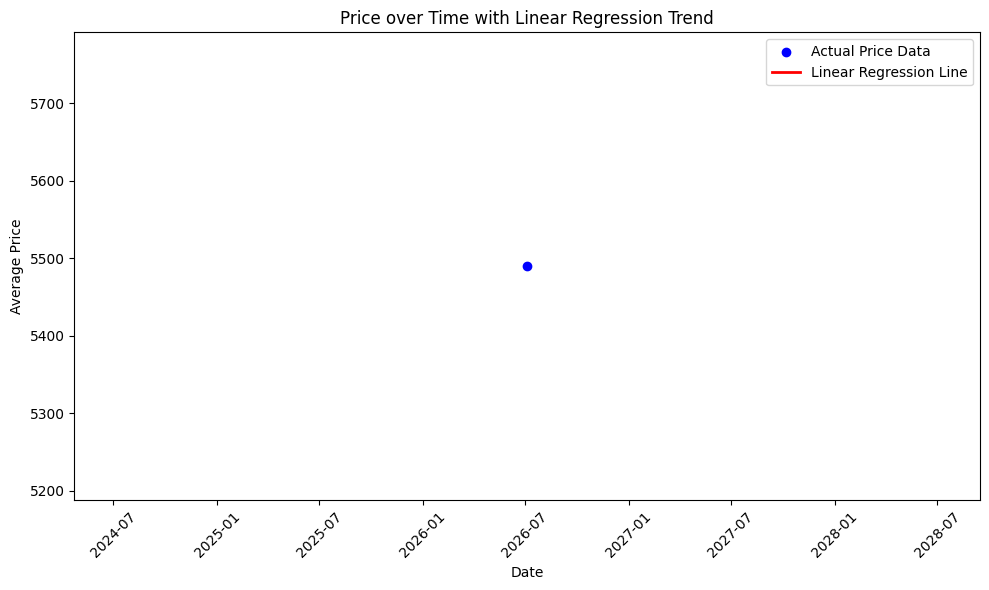

In [68]:
df_history_analysis = pd.read_csv('market_history.csv')
df_history_analysis['Date'] = pd.to_datetime(df_history_analysis['Date'])
df_history_analysis['Date_ordinal'] = df_history_analysis['Date'].apply(lambda x: x.toordinal())
X_features = df_history_analysis[['Date_ordinal']]
y_features = df_history_analysis['avg_price']
linear_regression_model = linear_model.LinearRegression()
linear_regression_model.fit(X_features, y_features)
y_pred = linear_regression_model.predict(X_features)
plt.figure(figsize=(10, 6))
plt.scatter(df_history_analysis['Date'], y_features, color='blue', label='Actual Price Data')
plt.plot(df_history_analysis['Date'], y_pred, color='red', linewidth=2, label='Linear Regression Line')

plt.xlabel('Date')
plt.ylabel('Average Price')
plt.title('Price over Time with Linear Regression Trend')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
def predict_price(target_date_str):
    target_date = pd.to_datetime(target_date_str)
    target_ordinal = target_date.toordinal()
    predicted_price = linear_regression_model.predict([[target_ordinal]])
    return predicted_price[0]

In [69]:
future_date =input("Enter the date for which you want to predict the price (YYYY-MM-DD): ")
predicted_val = predict_price(future_date)
print(f"The predicted price for {future_date} is: {predicted_val:.2f}")

Enter the date for which you want to predict the price (YYYY-MM-DD): 2026-07-05
The predicted price for 2026-07-05 is: 5489.57


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
